# Feature analysis — flow persistence (aggressor-sign long-memory)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builders** — the
`signed_trade` and `flow_sign_persistence` functions in §3. The data loading, the checks, and the
plots adapt on their own.

**The example** here is a *pair* of trades-only, bounded atoms built per venue on byb's shared
trade clock from the aggressor sign `ε_t = +1` (a buy that lifts the ask) / `−1` (a sell that hits
the bid):
- **`signed_trade = EMA(ε_t) ∈ [−1, 1]`** — the net signed direction of recent trades. This is the
  **directional** atom: when buyers dominate, byb's mid tends to tick up next.
- **`flow_sign_persistence = EMA(ε_t · ε_{t−1}) ∈ [−1, 1]`** — the serial correlation of trade
  sign: +1 when consecutive trades keep the same side (runs / momentum), −1 when they alternate
  (mean-reversion / ping-pong). This is a **regime gauge**: it says *whether the directional signal
  will persist*, not which way. The hypothesis is **Lillo–Farmer order-splitting**.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N`. (`σ_ev` is the exp-weighted RMS of byb's *actual*
mid-moves — read as an `E/W` ratio so the many non-move trades cancel out; `λ_ev` is a ratio of two
EMAs — the exp-weighted byb move-count `W` (the same `W` that is `σ_ev`'s denominator) ÷ the
exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live on the
trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed**:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. The long-memory of order flow this feature exploits is **Lillo & Farmer
(2004)** and **Bouchaud et al. (2004)**: aggressor sign is one of the most persistent series in
finance, because parent orders are split.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all (byb's own flow *and* the
  cross-venue bin/okx legs).
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. Both atoms
  are genuine per-exchange numbers (not gaps *between* exchanges), so first check per-exchange vs
  single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Both atoms are bounded `E / W` ratios in `[−1, 1]`, so they
  should need **no** vol/rate division — but we **measure** the regime-invariance scale (§5)
  before claiming it. Dividing a bounded ratio by `σ_ev` would *add* a regime dependence it
  doesn't have. (Contrast the template's price gap, which is bigger when volatile and so *must*
  be divided by `σ_ev`.)
- **Don't use a hard / boxcar / rolling window.** No rolling max/min, no fixed-N lookback buffer.
  The "persistence" is an **EMA** of the sign product `ε_t·ε_{t−1}`, *not* a Donchian / rolling
  autocorrelation over a window. Every smoother here is a trade-tick EMA.
- **Don't invent your own vol/rate scale.** When you *do* normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp; the lag
  `ε_{t−1}` is the venue's *previous* trade-timestamp sign, strictly in the past.

**Do**
- **Do start with a falsifiable hypothesis** — here, Lillo–Farmer order-splitting: aggressor sign
  has long memory, so a buy precedes more buys. What would disprove it: no continuation at any
  span, or power that vanishes once we control for volatility/rate.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the sign atoms,
  `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a trade on its own exchange — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do treat all records sharing a timestamp as ONE event.** A burst of trade prints stamped at
  the *exact same instant* (one order sweeping levels) did not arrive in an order — they are one
  event. The decay clock advances **once** per timestamp; the venue's sign for that timestamp is
  the sign of the *net* signed-count over that instant's prints — one `ε`, not a sequence (so the
  lag `ε_{t−1}` steps once per venue-timestamp, never once per print). Treating a same-instant
  burst as a sequence would fabricate phantom transitions in `ε_t·ε_{t−1}` — wrong for a
  serial-correlation statistic.
- **Do read a sparse flow as `E / W`.** Each atom is present only on *some* events (a given
  venue's trades), so it needs the trade-tick EMA as **two** of them — the value `E` and its
  weight `W` (here `W = EMA(1)` over that venue's trade-timestamps) — read as the ratio `E / W`,
  which cancels the in-between (foreign-venue) decay and the warm-up bias. Dividing by `W` cancels
  the foreign-event decay exactly, so an `E / W` on the **combined** trade clock at span `N`
  approximates that venue's **own**-clock EMA at a rescaled span — roughly `N` × that venue's share
  of the combined trade rate — i.e. you get genuine per-exchange stats from the one shared clock.
  (That merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N` where the
  cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** `signed_trade` is the
  directional atom; `flow_sign_persistence` is a regime gauge / interaction. Feed both signed;
  never a pre-computed `|feature|`. The rate head will learn the magnitude itself, *and* learn that
  buy pressure on one exchange can cancel sell pressure on another (or reinforce it). Pre-taking
  `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (both atoms are exactly such bounded ratios), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | per venue, on byb's trade clock: `signed_trade = EMA(ε_t)` (net buy/sell direction) and `flow_sign_persistence = EMA(ε_t·ε_{t−1})` (serial correlation of sign) |
| **feeds** | both heads — *direction* (price head: `signed_trade` → which way byb moves) and *intensity* (rate head); `flow_sign_persistence` is a regime gauge that says when continuation persists; both fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Tag every trade by its aggressor: `ε_t = +1` if it lifted the ask (an aggressive
buy), `ε_t = −1` if it hit the bid (an aggressive sell), using `io._trade_lifts_ask` for the
venue-specific convention. Then form two exponentially-weighted, bounded means on the trade clock:
- **`signed_trade = EMA(ε_t) ∈ [−1, 1]`** — near +1 when recent trades were mostly buys, near
  −1 when mostly sells, 0 when balanced. The **net direction** of aggressive flow.
- **`flow_sign_persistence = EMA(ε_t · ε_{t−1}) ∈ [−1, 1]`** — the product `ε_t·ε_{t−1}` is +1
  when two consecutive trades took the *same* side, −1 when they *alternated*. Its EMA is the
  recent **serial correlation** of sign: +1 ⇒ runs (continuation regime), −1 ⇒ ping-pong
  (mean-reversion regime).

**Why it should work.** Order flow is one of the most persistent series in finance
(**Lillo–Farmer 2004; Bouchaud et al. 2004**): a large parent order is *split* into many child
orders worked over seconds-to-minutes, so a buy is followed by more buys. That long memory means
(a) the net sign `signed_trade` carries directional information about byb's next move
(continuation), and (b) the *amount* of memory varies — when `flow_sign_persistence` is high, a
given `signed_trade` is more trustworthy (the run will continue); when it is low or negative, the
same net sign is noise. So `signed_trade` is the prediction and `flow_sign_persistence` gates it.

**What would disprove it.** No directional power from `signed_trade` at any span; or power that
vanishes once we account for how volatile / busy the market is (it was only tracking regime); or
`flow_sign_persistence` not actually modulating the directional edge.

> **No fixed leader.** Build both atoms the same way for **every** exchange — byb's own flow
> (its own contemporaneous pressure) *and* the cross-venue bin/okx legs (a foreign venue's flow
> that can *lead* byb) — and keep them all. §9 sweeps when per-exchange is worth it.

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). Both atoms are **sparse flows** — a given
venue's sign and sign-product exist only on *that venue's* trade-timestamps — so each is the textbook
case for the self-normalising `E / W` read. Choose the EMA type and injection rule for the statistic
being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (a per-exchange trade flow; byb's mid-moves): use
  **`KernelMeanEMA`**, the self-normalising `E / W`. `add(value, weight)` injects `E += α·value·weight`,
  `W += α·weight`; `value()` returns `E / W`.
  - `signed_trade`: inject `value = ε_t`, `weight = 1` on each of the venue's trade-timestamps →
    `E = EMA(ε)`, `W = EMA(1)`, read `E / W` = the count-weighted mean sign ∈ `[−1, 1]`.
  - `flow_sign_persistence`: inject `value = ε_t·ε_{t−1}`, `weight = 1` (the lag is the venue's
    previous trade-timestamp sign) → `E / W` = the mean sign-product ∈ `[−1, 1]`.
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap) — would use
  **`LiveFrontEMA`** instead. There is **no live front** here: both atoms are piecewise-constant
  between this venue's trades (no price level is involved), so the value as of the **last
  venue-trade at-or-before the anchor** is the freshest causal read.
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (both atoms: push the venue's one per-timestamp sign / sign-product only on a trade of *this* venue; `σ_ev`: push `r²` only on a byb move) |
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (gap, price) — not used here |

We inject **once per venue-timestamp**, on the sign of the *net* signed-count over that instant's
prints (same-timestamp prints are one event), and the lag `ε_{t−1}` steps once per venue-timestamp
too. Pushing once per *print* instead would fabricate extra same-instant transitions in
`ε_t·ε_{t−1}` (a phantom run or phantom reversal inside one order sweeping levels) — wrong for a
serial-correlation statistic. The §4 parity check enforces this.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed. The lag `ε_{t−1}` is the venue's
*previous* trade-timestamp sign, strictly earlier; the read at an anchor is the EMA committed at
the **last venue-trade at-or-before the anchor**.

**Measured on the trade clock** — both atoms decay once per trade-timestamp on the **shared** clock
(one tick per timestamp across all venues; simultaneous prints are one tick), and inject on that
venue's own trade-timestamps. Counting progress in trades (not seconds) keeps the meaning steady
whether trading is fast or slow.

**Comparable across calm and wild markets** — both atoms are bounded `E / W` ratios in `[−1, 1]`,
so they should be **invariant raw**: a buy run reads the same +0.6 whether the market is calm or
wild. We do **not** divide by `σ_ev` or `λ_ev` here — that would *add* a regime dependence. §5
**measures** the scale across volatility buckets to confirm it (raw-first; normalise only if it
fails).

**2a — the shapes** (the whole idea, per venue, span `N`, `α = 2/(N+1)`):

`signed_trade(N)            = EMA(ε_t)         = E[ε] / E[1]`
`flow_sign_persistence(N)   = EMA(ε_t·ε_{t−1}) = E[ε·ε_prev] / E[1]`

with `ε_t ∈ {−1, +1}` the venue's aggressor sign at trade-timestamp `t` (`io._trade_lifts_ask`),
and `ε_{t−1}` that venue's previous trade-timestamp sign. Stop here and you have the feature — the
rest is making each piece correct.

**2b — the EMAs and how they update** — both are **`KernelMeanEMA`** (`E/W` flow means):
`signed_trade` injects `(ε, weight 1)`, `flow_sign_persistence` injects `(ε·ε_prev, weight 1)`; both
decay once per shared-clock trade tick (`0` on a tick where this venue did not trade). No live front
(no level to forward-fill). `W` divides out the common foreign-venue decay and the warm-up bias.

**The yardsticks (built but not applied to either atom).** `σ_ev`, `λ_ev` are still needed: the
**target** is `byb return ÷ σ_ev` (price head) and `count ÷ λ_ev` (rate head), and they are the
regime **controls** in §5. They are `KernelMeanEMA` `E/W` reads over byb's mid-moves, span
`YARDSTICK_N`, decayed on the shared trade clock and updated on every byb mid-move.

§3 builds exactly this; §4 re-derives it from raw events and confirms it **bit-exact**.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block
import boba.io as io

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict; byb is also one of the venues whose flow we measure
EXCHANGES   = ["bin", "byb", "okx"]              # each venue's signed_trade + flow_sign_persistence is a feature (byb own + bin/okx cross-venue)
# freshest mid per exchange. byb/okx use merged_levels (BBO fused with trades); bin MUST use front_levels
# (merged_levels is DISALLOWED for bin perp in boba.io — it raises). Used only to BUILD the byb mid / yardsticks / target.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [5, 20, 100, 500, 2000, 8000]      # the trade-span family to sweep (EMA memory in trades)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, target + controls only
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load byb's mid-price stream (for the byb target + yardsticks); rows already arrive in time order
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("byb",)}

# load each exchange's TRADES: rx_time and the signed aggressor direction ε = +1 (lifts ask / buy) | -1 (hits bid / sell).
# Drop bad prc=qty=0 prints. io._trade_lifts_ask handles the venue-specific aggressor convention. (qty is NOT used — sign only.)
trades = {}
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty", "aggressor")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))
    rx   = td["rx_time"].cast(pl.Int64).to_numpy()
    sign = np.where(io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()), 1.0, -1.0)
    trades[ex] = (rx, sign)

# the shared trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints -> ONE tick.
trade_prints = np.concatenate([trades[ex][0] for ex in EXCHANGES])
merged_ts = np.unique(trade_prints)                             # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# byb mid on the clock (for σ_ev / λ_ev only — NOT used by either atom)
def mid_on_clock(ex):                            # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]
log_mid_byb = np.log(mid_on_clock("byb"))

# Both yardsticks react to EVERY byb merged-mid change — defined at every instant, never the net move per trade.
# They decay once per TRADE (memory in trade count) but INJECT on every byb mid-move, so a value read between
# trades reflects the moves since the last trade. σ_ev = √(E/W) over the byb-MOVE stream (E = squared returns,
# W = move count) — its E/W cancels the in-between trade decay. λ_ev = W / E_dt is a RATE: E_dt is a per-trade
# EMA of seconds/trade (flat between trades by construction), so λ_ev = byb mid-moves per second.
byb_rx0, byb_mid0 = mids["byb"]                                                   # raw byb merged mid stream (front_levels + trade fusion)
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (target + controls only)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (target + controls only)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade. They have to agree, which §4 checks
**bit-exact**.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
adjacent 100 ms windows overlap ~50%, so neighbouring samples are correlated, which is why §5's
walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the thing we
predict), and compute both atoms at each grid point for each exchange and span.

**The vectorized build.** For one venue and span `N` (`α = 2/(N+1)`): collapse the venue's
trades to **one sign per timestamp** — `ε = sign(Σ signed-count over that instant's prints)` (a
burst sweeping levels is one event). Drop a timestamp whose net is exactly 0 (no net side — a
rare tie). Place those per-timestamp signs on the shared clock and form, on each of *this venue's*
trade-timestamps, two injected marks: `ε_t` (for `signed_trade`) and `ε_t·ε_{t−1}` (for
`flow_sign_persistence`, `ε_{t−1}` = this venue's previous per-timestamp sign). Run an `E/W` pair
per atom — `E` over the mark, `W` over `1` — decayed once per **shared-clock** tick (0 on ticks
where this venue did not trade), and read `E/W` as committed just after the **last clock tick
at-or-before the anchor** (causal; piecewise-constant between this venue's trades). `lfilter` does
the recursion; we gather at each anchor's clock tick.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # = 50000: enough trades for the slowest EMA / yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# mid_now is the byb mid AT-OR-BEFORE the anchor (searchsorted "right"-1) — i.e. the POST-anchor-trade mid: a byb trade
# stamped exactly at the anchor has both fed the feature (≤ anchor) AND set mid_now. The forward return log(mid_fwd/mid_now)
# is STRICTLY forward (mid_fwd > mid_now in time), so there is NO hard leak into the future. But because the same anchor
# tick sets both the feature's sign and the post-trade mid_now, the δ=0 IC mechanically INCLUDES that just-executed tick —
# this is exactly the own-flow echo (the echo-netting section sizes it via the backward IC, and nets it out with the partial-IC gate).
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

# Per venue: one sign per TIMESTAMP = sign(Σ ε over that instant's prints); the venue's per-timestamp marks on the shared clock.
# eps_mark = ε_t (signed_trade);  prod_mark = ε_t·ε_{t-1} (persistence, lag = this venue's previous per-timestamp sign).
def _venue_marks(ex):
    rx, sign = trades[ex]
    # collapse this venue's same-timestamp prints to ONE event: net signed-count, then its sign (drop exact ties == 0)
    urx, inv = np.unique(rx, return_inverse=True)
    net = np.bincount(inv, weights=sign, minlength=len(urx))      # Σ ε over each timestamp's prints
    eps = np.sign(net)                                            # per-timestamp aggressor sign ∈ {-1,0,+1}
    nz  = eps != 0.0                                              # drop net-zero timestamps (no net side)
    urx, eps = urx[nz], eps[nz]
    prev = np.empty_like(eps); prev[0] = 0.0; prev[1:] = eps[:-1]  # this venue's PREVIOUS per-timestamp sign (lag); 0 before the 2nd trade
    prod = eps * prev                                            # ε_t·ε_{t-1} ∈ {-1,0,+1} (0 only on the venue's first trade)
    has_prev = prev != 0.0                                       # the product mark is defined from the venue's 2nd timestamp on
    k = np.searchsorted(merged_ts, urx, "left")                  # shared-clock tick index of each of this venue's timestamps (exact match)
    return k, eps, prod, has_prev
venue_marks = {ex: _venue_marks(ex) for ex in EXCHANGES}

def _ema_ratio(k, e_mark, w_mark, N):              # E/W on the shared clock: inject (mark, weight) at ticks k, decay every tick, committed value
    a = 2.0 / (N + 1.0)
    e_inj = np.bincount(k, weights=e_mark, minlength=n_ticks)    # Σ mark per clock tick (0 where this venue didn't trade)
    w_inj = np.bincount(k, weights=w_mark, minlength=n_ticks)    # Σ weight per clock tick
    E = lfilter([a], [1.0, -(1.0 - a)], e_inj)
    W = lfilter([a], [1.0, -(1.0 - a)], w_inj)
    return (E / np.where(W > 0.0, W, np.nan))[tick_at_anchor]    # E/W as of the last clock tick <= anchor (nan until this venue traded)

def signed_trade(ex, N):                           # EMA(ε) = E[ε]/E[1] ∈ [-1, 1]
    k, eps, prod, has_prev = venue_marks[ex]
    return _ema_ratio(k, eps, np.ones_like(eps), N)
def flow_sign_persistence(ex, N):                  # EMA(ε_t·ε_{t-1}) = E[ε·ε_prev]/E[1] ∈ [-1, 1] (weight only on timestamps with a prev sign)
    k, eps, prod, has_prev = venue_marks[ex]
    return _ema_ratio(k, prod * has_prev, has_prev.astype(float), N)
print(f"grid: {len(anchor_ts):,} anchors;  spans {SPANS};  two atoms x {len(EXCHANGES)} venues")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors;  spans [5, 20, 100, 500, 2000, 8000];  two atoms x 3 venues


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce **both** atoms with a second implementation and confirm the two
agree on real data, **bit-exact** (`< 1e-12`). The streaming build is the **production** reference:
an O(1) state machine you push **raw trade events** into and read both atoms per venue from
`value(ex)`. State is four scalar EMAs per venue (`E,W` for `signed_trade`, `E,W` for
`flow_sign_persistence`) plus the venue's previous sign — no buffers, no history, independent of how
long it runs.

**The design:**
- Fed **only raw trade events**, each tagged by its venue. `on_trade(ex, sign)` accumulates the
  timestamp's net signed-count (`+= sign`) — summing same-instant prints — without touching the clock.
- The driver groups events by **receive-timestamp**: it applies all of a timestamp's trades, then
  calls **`refresh()` once** — which decays *every* venue's EMAs by one shared-clock tick, then,
  for each venue that traded, resolves its one per-timestamp sign `ε = sign(net)` (skip if net
  == 0), injects `ε` into `signed_trade`'s `(E,W)` and `ε·ε_prev` into `flow_sign_persistence`'s
  `(E,W)` (the latter only once a previous sign exists), and updates `ε_prev = ε`.
- `value(ex)` returns `(signed_trade, flow_sign_persistence)` = `(E/W, E/W)` for that venue.

This is deliberately a different code path from §3 (an explicit per-event loop with
`KernelMeanEMA`, no `lfilter`, no `bincount`), with the genuinely independent **logic** — the
same-timestamp net→sign collapse, the lag `ε_{t−1}`, the net==0 tie-drop — re-derived from scratch.
We feed the **whole raw trade stream** (every venue) into **one** builder and read **all three**
venues' atoms at each grid anchor. If the online build reproduces §3's vectorized atoms, the two
implementations agree.

In [3]:
from boba.ema import KernelMeanEMA          # the E/W flow mean — add(value, weight): E += a*value*weight, W += a*weight

class LiveFlowPersistence:
    # Pure feature state machine. Per venue: a KernelMeanEMA for signed_trade (E[ε]/E[1]) and one for
    # flow_sign_persistence (E[ε·ε_prev]/E[1]), plus the scalar previous-sign ε_prev. on_trade ACCUMULATES the
    # current timestamp's net signed-count (sum of same-instant prints). refresh() advances the SHARED trade clock
    # exactly once per timestamp: decay every venue's EMAs, then for each venue that traded resolve ε = sign(net),
    # inject ε (signed_trade) and ε·ε_prev (persistence, once ε_prev exists), and roll ε_prev = ε. O(1) scalar state.
    def __init__(self, exchanges, span):
        self.exchanges = list(exchanges)
        self.st  = {ex: KernelMeanEMA(span) for ex in exchanges}   # signed_trade:           add(ε, 1)        -> E[ε]/E[1]
        self.per = {ex: KernelMeanEMA(span) for ex in exchanges}   # flow_sign_persistence:  add(ε·ε_prev, 1) -> E[ε·ε_prev]/E[1]
        self.net = {ex: 0.0 for ex in exchanges}                   # pending net signed-count this timestamp (a SUM is one event)
        self.dirty = {ex: False for ex in exchanges}               # did this venue trade this timestamp?
        self.prev = {ex: 0.0 for ex in exchanges}                  # this venue's previous per-timestamp sign (0 before its first)

    def on_trade(self, ex, sign):                                  # one trade print -> add to this timestamp's net signed-count
        self.net[ex] += sign
        self.dirty[ex] = True

    def refresh(self):                                             # ONE shared-clock tick per TIMESTAMP: decay all, then inject each venue's one sign
        for ex in self.exchanges:
            self.st[ex].tick(); self.per[ex].tick()                # decay both EMAs — the shared clock advanced once
            if self.dirty[ex]:
                eps = 1.0 if self.net[ex] > 0.0 else (-1.0 if self.net[ex] < 0.0 else 0.0)
                if eps != 0.0:                                     # a net side this timestamp (skip exact ties)
                    self.st[ex].add(eps, 1.0)                      # E[ε] / E[1]
                    if self.prev[ex] != 0.0:                       # the product mark needs a previous sign (venue's 2nd trade on)
                        self.per[ex].add(eps * self.prev[ex], 1.0)  # E[ε·ε_prev] / E[1]
                    self.prev[ex] = eps                            # roll the lag forward by one venue-timestamp
                self.net[ex] = 0.0; self.dirty[ex] = False

    def value(self, ex):
        return self.st[ex].value(), self.per[ex].value()          # (signed_trade, flow_sign_persistence); nan before enough trades

# --- gather the WHOLE raw trade stream (every venue) over a slice, tagged & rx-sorted ---
# Validate at the SHIPPED price-head span (20) AND a second span (100) — the recursion is the SAME for every span, but
# checking the actually-shipped span closes the gap at zero cost. Same-timestamp net-sign collapse, the net==0 tie-drop,
# and the lag `has_prev` masking are span-INDEPENDENT logic, all exercised here.
SPANS_CHK, N_GRID = [20, 100], 40_000              # spans to validate; first ~N_GRID grid anchors
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])
rx_all, ex_all, s_all = [], [], []
for ei, ex in enumerate(EXCHANGES):
    rx, sign = trades[ex]
    m = rx <= cutoff
    rx_all.append(rx[m]); ex_all.append(np.full(int(m.sum()), ei, np.int8)); s_all.append(sign[m])
rx_all = np.concatenate(rx_all); ex_all = np.concatenate(ex_all); s_all = np.concatenate(s_all)
order  = np.argsort(rx_all, kind="stable")         # rx ascending (a timestamp's prints stay grouped; intra-timestamp order is irrelevant — we SUM)
rxL = rx_all[order].tolist(); exL = ex_all[order].tolist(); sL = s_all[order].tolist()
na = min(N_GRID, len(anchor_ts))
cover = 100.0 * na / len(anchor_ts)                # honest coverage fraction of the full grid
print(f"streaming {len(rxL):,} raw trade events (all venues) over {na:,} grid anchors "
      f"({cover:.1f}% of the {len(anchor_ts):,}-anchor grid) at spans {SPANS_CHK}...")

# --- the CALLER drives it: apply each timestamp's trades, refresh() once per timestamp, READ value() at every grid anchor ---
def _run_stream(span):                             # stream the raw events once at this span; return per-venue (signed_trade, persistence) arrays
    feat = LiveFlowPersistence(EXCHANGES, span)
    st_s  = {ex: np.full(na, np.nan) for ex in EXCHANGES}
    pr_s  = {ex: np.full(na, np.nan) for ex in EXCHANGES}
    n = len(rxL); i = 0; ai = 0
    while i < n:
        rx = rxL[i]
        while ai < na and anchor_ts[ai] < rx:      # read every anchor whose state is settled (all trades before rx applied)
            for ex in EXCHANGES:
                s, p = feat.value(ex); st_s[ex][ai] = s; pr_s[ex][ai] = p
            ai += 1
        while i < n and rxL[i] == rx:              # apply EVERY trade stamped at this nanosecond (no half-applied timestamp)
            feat.on_trade(EXCHANGES[exL[i]], sL[i])
            i += 1
        feat.refresh()                             # advance the shared clock ONCE: decay all, inject each venue's one sign
    while ai < na:                                 # trailing anchors after the last event
        for ex in EXCHANGES:
            s, p = feat.value(ex); st_s[ex][ai] = s; pr_s[ex][ai] = p
        ai += 1
    return st_s, pr_s

# --- one stream -> two atoms x three venues: check EACH against its §3 vectorized build, BIT-EXACT, at every span ---
worst = 0.0
for SPAN_CHK in SPANS_CHK:
    st_stream, per_stream = _run_stream(SPAN_CHK)
    tag = " (SHIPPED span)" if SPAN_CHK == 20 else ""
    print(f"one raw-trade stream -> two atoms x three venues, vs the vectorized build (span={SPAN_CHK}){tag}:")
    for ex in EXCHANGES:
        for name, stream, ref in [("signed_trade", st_stream[ex], signed_trade(ex, SPAN_CHK)[:na]),
                                  ("flow_sign_persistence", per_stream[ex], flow_sign_persistence(ex, SPAN_CHK)[:na])]:
            both = np.isfinite(stream) & np.isfinite(ref)
            diff = np.abs(stream[both] - ref[both])
            md_ = float(np.nanmax(diff)); worst = max(worst, md_)
            print(f"  {ex:4} {name:24} max |diff| {md_:.2e}  on {int(both.sum()):,} grid points")
            assert md_ < 1e-12, f"live build does not reproduce {ex} {name} bit-exactly at span {SPAN_CHK}"
print(f"parity: one raw-trade stream reproduces BOTH atoms x ALL THREE venues bit-exactly at spans {SPANS_CHK}  (worst {worst:.2e})  OK")

streaming 585,061 raw trade events (all venues) over 40,000 grid anchors (2.3% of the 1,706,369-anchor grid) at spans [20, 100]...


one raw-trade stream -> two atoms x three venues, vs the vectorized build (span=20) (SHIPPED span):


  bin  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  bin  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
  byb  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  byb  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
  okx  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  okx  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points


one raw-trade stream -> two atoms x three venues, vs the vectorized build (span=100):
  bin  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  bin  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
  byb  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  byb  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
  okx  signed_trade             max |diff| 0.00e+00  on 40,000 grid points
  okx  flow_sign_persistence    max |diff| 0.00e+00  on 40,000 grid points
parity: one raw-trade stream reproduces BOTH atoms x ALL THREE venues bit-exactly at spans [20, 100]  (worst 0.00e+00)  OK


**Conclusion.** From one stream of ~585k raw trade events the streaming builder reproduces **both
atoms** for **all three** venues **bit-exactly** — `max |diff| = 0.00e+00` (exactly zero, not merely
floating-point-close) over the ~2.3% grid slice (40,000 anchors), at **both** the shipped span (20)
and span 100. That the two recursions (vectorized `lfilter` vs an explicit per-event `KernelMeanEMA`
loop, no shared §3 code) agree to the *bit* is not luck here: the injected marks are **integer ±1**
(`ε` and `ε·ε_prev`), the per-tick weight is exactly `1`, the decay `α = 2/(N+1)` is identical, and
both paths see the **same tick order** — so both recursions accumulate the *same* IEEE-754 operations
in the *same* order and round identically. (A forward-filled level fed real-valued samples, like the
template's gap, instead drifts ~1e-13 in the last digit; this atom's ±1 marks make it exact.) The
production shape (one feed in, two atoms *per venue* out, the lag carried as a single scalar) computes
exactly what the offline analysis did, on the one shared trade clock — so the §3 build is trustworthy.
The recursion is identical for every span (only `α` changes), so validating spans 20 and 100 validates
the family; the genuinely span-*independent* logic — same-timestamp net→sign collapse, the net==0
tie-drop, the lag `has_prev` masking — is exercised at every span anyway.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — longer than the ~100 s embargo. The **shipped**
price-head span is short (N≈20), so the headline is unaffected; but the long-span family members
(up to 8000) and the `YARDSTICK_N=10000` controls still carry memory across the train→test boundary,
so re-check those if you slow the spans or use a thinner-traded block. The fold scores on the *next*
segment, and we average over folds. That's the causal, production-style estimate — strictly
past→future, as it would run live. (A single 60/40 split is a faster screen, but it tests only one
transition and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because both atoms are bounded `[−1, 1]` and the target is in σ-units, a *scale* regime-shift mostly cancels —
but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

> **Note on normalisation (raw-first).** Both atoms are bounded `[−1, 1]` ratios, so we ship them
> **raw** — *if* the scale gate passes. The target is still `return ÷ σ_ev` and the controls are
> still the yardsticks, so the gates are identical; we just don't σ/λ-divide the feature itself.
> The regime-invariant scale gate below is where "raw is fine" is **proven, not assumed**.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal.
FEATURE_KIND = "alpha"                                                  # aggressor-sign order flow = a directional signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
levels = [rate_level, vol_level]                                       # the regime COORDINATE (used only for Gate A / the no-leak check), NEVER controls
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale,
                                                                       # where a linear partial over-removes genuine within-yardstick signal. Both atoms are bounded
                                                                       # E/W ratios in [-1,1] that do NOT divide by σ_ev (nor λ_ev) at all — they share NO denominator
                                                                       # with either target — so there is no shared-yardstick coupling to decouple -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — that is
what we want: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows
*on top of* these controls is genuinely new information. That makes the "added over the controls"
gates below a fair test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every span), and
this feature is a *pair* of atoms. We check two things per atom:
- does the **signed** atom predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

`signed_trade` is the **directional** atom (its job is the price head). `flow_sign_persistence` is
a **regime gauge**: on its own it is roughly sign-free (a buy-run and a sell-run both read high
persistence), so its *signed* value is a weak directional predictor — its real use is as an
**interaction** that tells the model when `signed_trade` will continue. We sweep the whole span
family, for **every venue**, both atoms, against both targets, as heat-maps; we also test the
interaction `signed_trade · flow_sign_persistence` directly in the gates. We keep *all* venues.

**How many exchanges to keep is itself time-scale-dependent.** Aggressive flow on one venue leads
the others by a beat, so at **short** spans the venues genuinely differ (who's buying now) and the
atom is worth keeping **per-exchange**; at **long** spans the flow smooths toward a common drift
and one venue says much of what the rest do. Keep all as the default; §9 sweeps the cross-over.

**A second span only earns its place if it's orthogonal to the first** (the cell after the pick):
the IC sweep names the best span per head, but a nearby span can just be a diluted copy. We re-score
the family **conditional on the chosen span** (partial-IC) and let a walk-forward joint-vs-solo test
decide whether to keep a second time-scale.

The rate-head target is the count of byb's moves over the next 100 ms, divided by `λ_ev`.

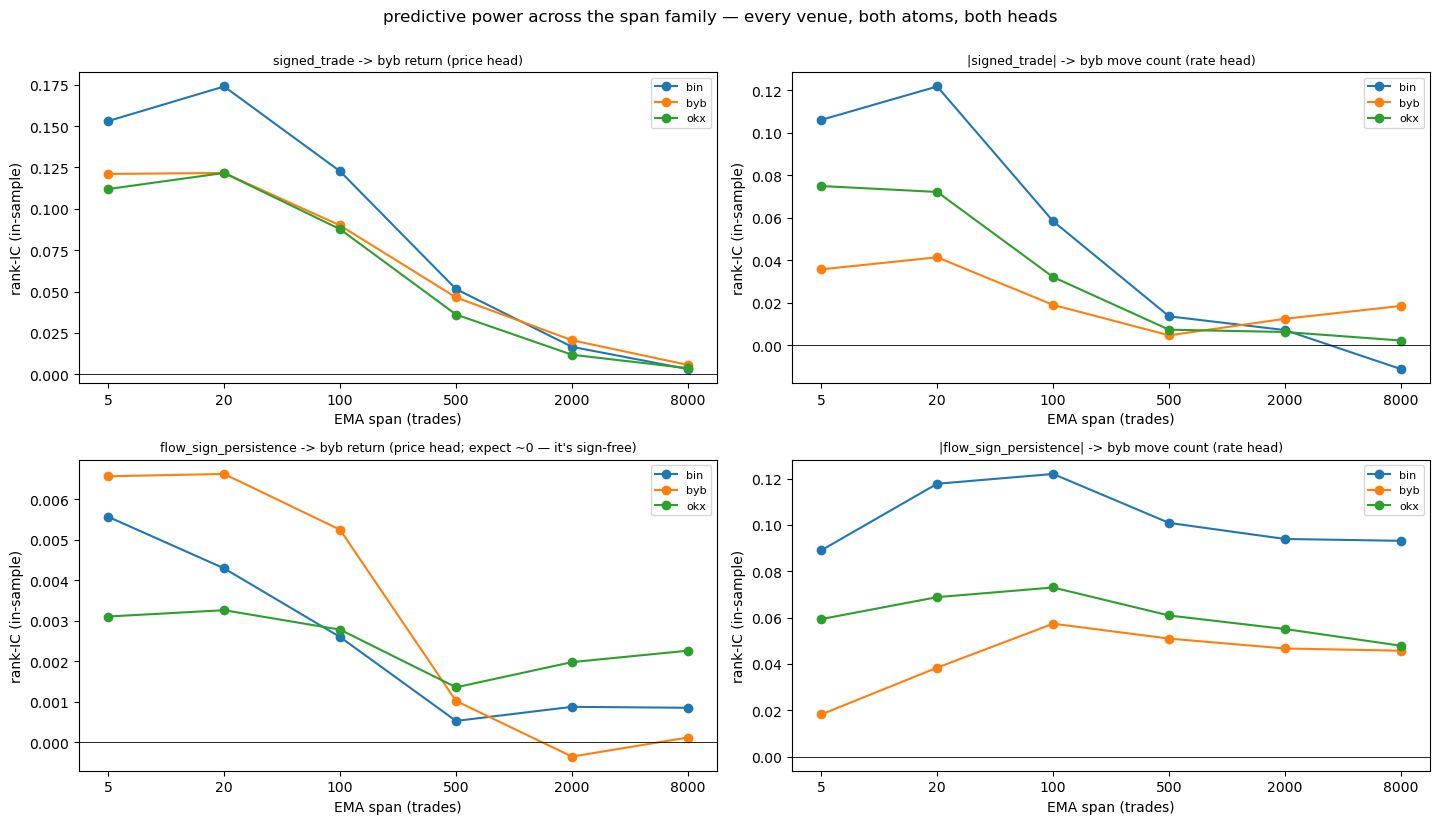

kept features (one signed_trade per venue, all fed — none privileged; persistence as a gauge):
  bin:  signed_trade price (span=20) IC=+0.174  | rate (span=20) IC=+0.122  | persistence gauge span=100 (IC vs count +0.122)
  byb:  signed_trade price (span=20) IC=+0.122  | rate (span=20) IC=+0.041  | persistence gauge span=100 (IC vs count +0.057)
  okx:  signed_trade price (span=20) IC=+0.122  | rate (span=5) IC=+0.075  | persistence gauge span=100 (IC vs count +0.073)


In [5]:
# rate-head target = byb moves (trade clock) in the next 100 ms ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (λ_ev is moves/sec over 100 ms, so this carries units of seconds; the constant horizon factor drops out of the rank correlation)

# Sweep the span family for EVERY venue, BOTH atoms, BOTH heads, treating venues symmetrically (no assumed leader).
st_cache  = {(ex, N): signed_trade(ex, N)           for ex in EXCHANGES for N in SPANS}
per_cache = {(ex, N): flow_sign_persistence(ex, N)  for ex in EXCHANGES for N in SPANS}
# price head: SIGNED atom -> byb signed return; rate head: |atom| -> byb move count
st_price  = {ex: np.array([spearmanr(st_cache[(ex, N)],  target).statistic      for N in SPANS]) for ex in EXCHANGES}
st_rate   = {ex: np.array([spearmanr(np.abs(st_cache[(ex, N)]),  rate_target).statistic for N in SPANS]) for ex in EXCHANGES}
per_price = {ex: np.array([spearmanr(per_cache[(ex, N)], target).statistic      for N in SPANS]) for ex in EXCHANGES}
per_rate  = {ex: np.array([spearmanr(np.abs(per_cache[(ex, N)]), rate_target).statistic for N in SPANS]) for ex in EXCHANGES}

fig, axes = plt.subplots(2, 2, figsize=(14.5, 8.2))
panels = [(axes[0][0], st_price,  "signed_trade -> byb return (price head)"),
          (axes[0][1], st_rate,   "|signed_trade| -> byb move count (rate head)"),
          (axes[1][0], per_price, "flow_sign_persistence -> byb return (price head; expect ~0 — it's sign-free)"),
          (axes[1][1], per_rate,  "|flow_sign_persistence| -> byb move count (rate head)")]
for ax, grids, head in panels:
    for ex in EXCHANGES:
        ax.plot(range(len(SPANS)), grids[ex], "o-", label=ex)
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS)
    ax.set_xlabel("EMA span (trades)"); ax.set_ylabel("rank-IC (in-sample)")
    ax.axhline(0, color="k", lw=0.6); ax.set_title(head, fontsize=9); ax.legend(fontsize=8)
fig.suptitle("predictive power across the span family — every venue, both atoms, both heads", y=1.00)
fig.tight_layout(); plt.show()

# We do NOT pick a venue. Every venue is kept; we only pick the best span PER head PER venue (in-sample),
# then re-score OUT-OF-SAMPLE in the §5 gates below — that is the number that counts.
def best_span(grid): return int(np.nanargmax(grid))
price_member = {ex: best_span(st_price[ex])  for ex in EXCHANGES}   # signed_trade is the directional atom -> price-head pick
rate_member  = {ex: best_span(st_rate[ex])   for ex in EXCHANGES}   # rate-head pick (|signed_trade|)
pers_member  = {ex: best_span(per_rate[ex])  for ex in EXCHANGES}   # the persistence span that best gauges intensity (for the interaction)
print("kept features (one signed_trade per venue, all fed — none privileged; persistence as a gauge):")
for ex in EXCHANGES:
    pj, rj, sj = price_member[ex], rate_member[ex], pers_member[ex]
    print(f"  {ex}:  signed_trade price (span={SPANS[pj]}) IC={st_price[ex][pj]:+.3f}"
          f"  | rate (span={SPANS[rj]}) IC={st_rate[ex][rj]:+.3f}"
          f"  | persistence gauge span={SPANS[sj]} (IC vs count {per_rate[ex][sj]:+.3f})")

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  bin: chosen span=20; best alt span=2000 IC|chosen -0.051;  OOS joint +0.164 vs solo +0.161 (Δ+0.004)  ->  one span suffices (no OOS gain)


  byb: chosen span=20; best alt span=2000 IC|chosen -0.017;  OOS joint +0.116 vs solo +0.117 (Δ-0.000)  ->  one span suffices (no OOS gain)


  okx: chosen span=20; best alt span=2000 IC|chosen -0.042;  OOS joint +0.117 vs solo +0.115 (Δ+0.002)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  bin: chosen span=20; best alt span=5 IC|chosen +0.035;  OOS joint +0.112 vs solo +0.112 (Δ+0.000)  ->  one span suffices (no OOS gain)


  byb: chosen span=20; best alt span=8000 IC|chosen +0.018;  OOS joint +0.044 vs solo +0.043 (Δ+0.001)  ->  one span suffices (no OOS gain)


  okx: chosen span=5; best alt span=20 IC|chosen +0.027;  OOS joint +0.073 vs solo +0.073 (Δ+0.000)  ->  one span suffices (no OOS gain)


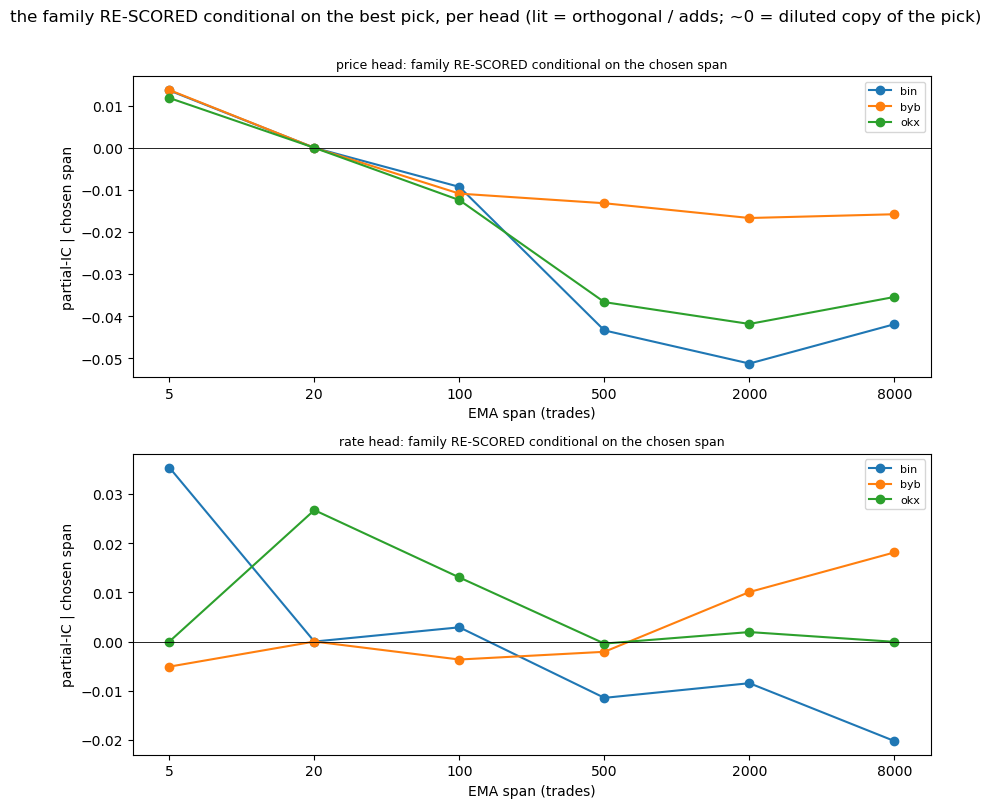

In [6]:
# === Does a SECOND time-scale ADD over the pick? — the family RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best span per head by IC; now re-score the WHOLE span family as
# partial-IC(cell | chosen) -- each span's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move). The family
# is a 1-D span sweep here (signed_trade(ex, N) / |signed_trade|(ex, N)), so this is a per-head LINE, not a heat-map.
# A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES to ~0 is a diluted copy. The lines are
# in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a span to its scored feature (price = signed_trade; rate = |signed_trade|), tgt is the
# head's target, member is the in-sample pick (an index into SPANS).
HEADS = [("price head", lambda ex, N: signed_trade(ex, N),         target,      price_member),
         ("rate head",  lambda ex, N: np.abs(signed_trade(ex, N)), rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), 1, figsize=(9.0, 4.0 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    ax = axes[row][0]
    for ex in EXCHANGES:
        cj = member[ex]; chosen = feat(ex, SPANS[cj])
        cond = np.full(len(SPANS), np.nan)
        for j, N in enumerate(SPANS):
            cond[j] = 0.0 if j == cj else _pic(feat(ex, N), tgt, chosen)
        ax.plot(range(len(SPANS)), cond, "o-", label=ex)
        bj = int(np.nanargmax(np.abs(cond)))                                       # the most-orthogonal alternative span (in-sample screen)
        f1, f2 = chosen, feat(ex, SPANS[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = bj if keep else None
        print(f"  {ex}: chosen span={SPANS[cj]}; best alt span={SPANS[bj]} IC|chosen {cond[bj]:+.3f};"
              f"  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
    ax.axhline(0, color="k", lw=0.6); ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS)
    ax.set_xlabel("EMA span (trades)"); ax.set_ylabel("partial-IC | chosen span")
    ax.set_title(f"{head}: family RE-SCORED conditional on the chosen span", fontsize=9); ax.legend(fontsize=8)
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC sweep picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole span family conditional
on the chosen pick** — each span's IC recomputed as `partial-IC(span | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell uses;
control = the chosen span). A span that stays **lit** is **orthogonal** — it adds new signal — while a span that
**collapses to ≈ 0** is a diluted copy of the pick. Because that screen is **in-sample**, the keep/drop **decision**
is the overfitting-resistant **walk-forward joint-vs-solo** IC (`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the
second span only when the out-of-sample gain clears the ~0.01 floor. We run it for **both heads** (price → signed
`signed_trade` vs the σ-return target; rate → `|signed_trade|` vs the count target).

**Reading the heat-maps.** The **top-left** panel is where this feature lives: `signed_trade`'s
**signed** value correlates positively with byb's next return — a buy run precedes an up-tick (the
Lillo–Farmer continuation). On this block the IC peaks at the **short span (N=20)** for every venue
and decays toward 0 by the long spans (N≥2000) — sign autocorrelation is strongest in the freshest
trades. Here **bin leads the price head** (+0.174 in-sample at N=20) ahead of **byb (+0.122)** and
**okx (+0.122)** — bin's sub-ms-fresh trade feed gives the cleanest read. The **bottom-left** panel
confirms the design intuition: `flow_sign_persistence`'s *signed* value is a near-zero directional
predictor because it is **sign-free** — high persistence in a sell run and a buy run alike — so its
*only* possible value is as a **regime gauge / interaction** (`signed_trade · persistence`), which we
test directly in the gates below. The **right** panels are the rate-head diagnostics (weaker; bin
+0.122, okx +0.075, byb +0.041 at the rate pick). We keep every venue and let the model weight
whoever is leading.

**Now the gates** (from §5), on the per-venue features we just chose, **plus** the persistence
interaction. Every predictive number here is the **walk-forward** mean (causal, purged, embargoed),
binding the shared `boba.research.gates` library through the §5 wrappers. *Marginal value:* does
`signed_trade` add over the controls — all venues together, and each on its own? *Persistence
interaction:* does adding the `signed_trade · flow_sign_persistence` product (the Lillo–Farmer gate —
"trust the direction more when sign is persistent") add *further*, over `signed_trade` alone?
*No leak:* is each atom's distribution stable against the regime (Gate A — scale within ~3×, and
neither the signed atom nor its magnitude tracking the vol/rate coordinate)? *Regime-stable*
(companion): is the marginal still positive within calm / mid / wild vol?

In [7]:
# Gates on the set of per-venue features — symmetric; KEEP ALL venues. signed_trade is the directional alpha;
# the persistence INTERACTION signed_trade*persistence is the Lillo-Farmer "trust the run" gate.
# signal_ic / signal_ic_by_regime / stratified_ic / ic / wf_ic come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). Both atoms are bounded E/W alphas -> all legs take the marginal branch.
sigtr = {ex: st_cache[(ex, SPANS[price_member[ex]])] for ex in EXCHANGES}              # chosen price-head signed_trade per venue
inter = {ex: sigtr[ex] * per_cache[(ex, SPANS[pers_member[ex]])] for ex in EXCHANGES}  # signed_trade * persistence (the gate/interaction)
joint = signal_ic(list(sigtr.values()), own=False)                                     # signed_trade marginal over the controls (walk-forward)
# marginal of the persistence INTERACTION over signed_trade alone (the Lillo-Farmer thesis test) — walk-forward delta
joint_int = round(wf_ic(base + list(sigtr.values()) + list(inter.values()), target)
                  - wf_ic(base + list(sigtr.values()), target), 3)
strat = signal_ic_by_regime(list(sigtr.values()), own=False)                           # the calm/mid/wild companion
pci   = wf_marginal_ci(list(sigtr.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
print(f"persistence interaction marginal over signed_trade (Lillo-Farmer gate): {joint_int:+.3f}")
rep = sigtr[EXCHANGES[0]]                               # representative leg — for the momenta-overlap sanity print only (Gate A runs PER EXCHANGE below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER EXCHANGE
# (Gate A is a property of the output DISTRIBUTION, which differs by venue — bin is sub-ms fresh, byb/okx stale):
# scale, plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone, e.g. U-shaped, leak the monotone IC misses); each row reports the WORST coordinate.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="all venues' signed_trade together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{ex} signed_trade alone — marginal over the controls",
                   value=signal_ic([sigtr[ex]], own=False)) for ex in EXCHANGES]
gate_rows += [dict(gate="B · interaction", detail="add signed_trade*persistence over signed_trade (Lillo-Farmer gate)", value=joint_int)]
# σ_ev-coupling confirmation: signed_trade divides by NO yardstick (STRAT_VAR=None). A within-σ_ev stratified standalone IC
# ≈ the unstratified standalone IC confirms σ_ev isn't manufacturing the rank-IC (no spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed_trade standalone IC, unstratified", value=round(ic(sigtr[ex], target), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(sigtr[ex], target, sigma_at_anchor), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:                                    # GATE A PER EXCHANGE (worst coordinate per check) — every venue, since the output distribution differs by venue
    a = gate_a(sigtr[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="signed_trade scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
# persistence atom is bounded too — report its scale across vol buckets for the raw-form claim
pa = gate_a(per_cache[(EXCHANGES[0], SPANS[pers_member[EXCHANGES[0]]])])
gate_rows += [dict(gate="A · regime-inv (persist)", detail=f"flow_sign_persistence ({EXCHANGES[0]}) scale across vol buckets (max/min) — want < ~3", value=pa["scale"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(60)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.167  |  per-fold [0.163, 0.173, 0.137, 0.148, 0.213] (positive in 5/5)  |  block-bootstrap 90% CI [0.161, 0.173]  (block ~2000 anchors ~100.0s)
persistence interaction marginal over signed_trade (Lillo-Farmer gate): -0.003


FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.031 vol 0.033  (large for an 'alpha' => it's really a control)


gate,detail,value
str,str,f64
"""B · signal""","""all venues' signed_trade together — marginal over the invari…",0.167
"""B · signal""","""bin signed_trade alone — marginal over the controls""",0.158
"""B · signal""","""byb signed_trade alone — marginal over the controls""",0.113
"""B · signal""","""okx signed_trade alone — marginal over the controls""",0.111
"""B · interaction""","""add signed_trade*persistence over signed_trade (Lillo-Farmer…",-0.003
"""B · coupling""","""bin — signed_trade standalone IC, unstratified""",0.174
"""B · coupling""","""byb — signed_trade standalone IC, unstratified""",0.122
"""B · coupling""","""okx — signed_trade standalone IC, unstratified""",0.122
"""B · coupling""","""bin — signed standalone IC WITHIN σ_ev strata (≈ unstratifie…",0.172


**Conclusion — read the numbers, including the unflattering ones.**

- **`signed_trade` marginal value (+0.167 joint) is real but it is ~95% bin.** The joint walk-forward
  marginal over the controls is **+0.167**, positive in **5/5** OOS folds (per-fold
  `[0.163, 0.173, 0.137, 0.148, 0.213]`) with a tight block-bootstrap 90% CI **[0.161, 0.173]**. But
  **bin alone is +0.158** — so byb (+0.113) and okx (+0.111) *together* add only **~0.009** over bin.
  The price-head signal is essentially a **single-venue (bin) result**. We still keep byb/okx, but the
  honest justification is **rotating leadership** (bin is not always the leader; carrying all three is
  cheap insurance worth ~0.01 of joint IC), **not** "every venue adds materially."
- **The persistence interaction earns nothing (−0.003).** The whole thesis of
  `flow_sign_persistence` — Lillo–Farmer "trust the run" — is that `signed_trade · persistence` adds
  **over** `signed_trade` alone. The measured walk-forward marginal is **−0.003** (slightly
  *negative*). On the data, the interaction is **worthless for its stated purpose.** The only positive
  evidence is the §7 "steeper tilt" visual; the quantitative OOS gate says it adds nothing — so we
  **demote** `flow_sign_persistence`: it is **measured-neutral**, kept (if at all) on the Lillo–Farmer
  prior as a cheap auxiliary input, **not** because it earns its place. See §10.
- **σ_ev-coupling: not an artefact.** `signed_trade` divides by no yardstick, and the within-σ_ev
  stratified standalone IC barely moves from the unstratified one (bin 0.174→0.172, byb 0.122→0.122,
  okx 0.122→0.121), confirming σ_ev isn't manufacturing the rank-IC. Its overlap with the momenta is
  tiny (|IC| rate 0.031, vol 0.033) — it really is an alpha, not a control.
- **Gate A (regime-invariant, HARD): passed.** Both atoms are bounded `[−1, 1]` ratios built
  **without** σ/λ-division; the per-venue scale ratios across vol buckets are **1.07 / 1.03 / 1.09**
  (bin / byb / okx; ≪ 3), and the persistence atom's scale is **1.07** — confirming **raw is the right
  form** (proven, not assumed). The magnitude the rate head can learn only weakly tracks the regime
  (mag-track 0.051 / 0.02 / 0.019; dispersion 0.063 / 0.037 / 0.06, all under ~0.1). The one number to
  watch is **bin's signed mean-track 0.055**, just brushing the ~0.05 bar (byb 0.029, okx 0.018 are
  clean) — worth re-checking across blocks, but not a failure. The companion keeps the marginal
  positive — and *rising* — across regimes (**0.156 / 0.169 / 0.181** for calm / mid / wild).

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

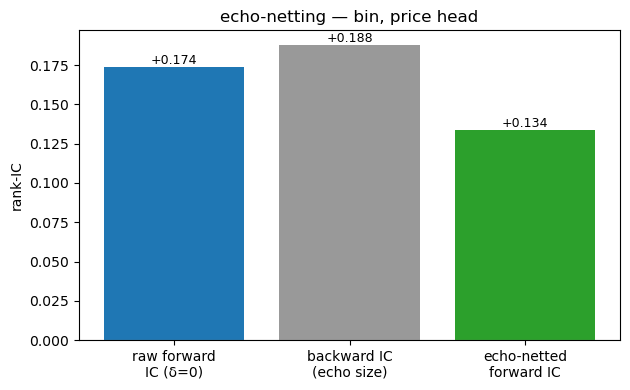

raw forward IC +0.174;  backward (echo) IC +0.188;  echo-netted forward IC +0.134  (the raw->netted shortfall is echo)


In [8]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = EXCHANGES[0]                                    # one exchange to illustrate; every feature carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = signed_trade(rep_ex, SPANS[price_member[rep_ex]])  # the chosen price-head feature (signed_trade, this venue's pick)
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the
feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for strong-sell / balanced / strong-buy `signed_trade` — it
  should tilt down when sellers dominate and up when buyers do;
- **rate head:** how the number of upcoming moves grows as `|signed_trade|` grows;
- **the persistence gauge:** does a high `flow_sign_persistence` *sharpen* the directional tilt?

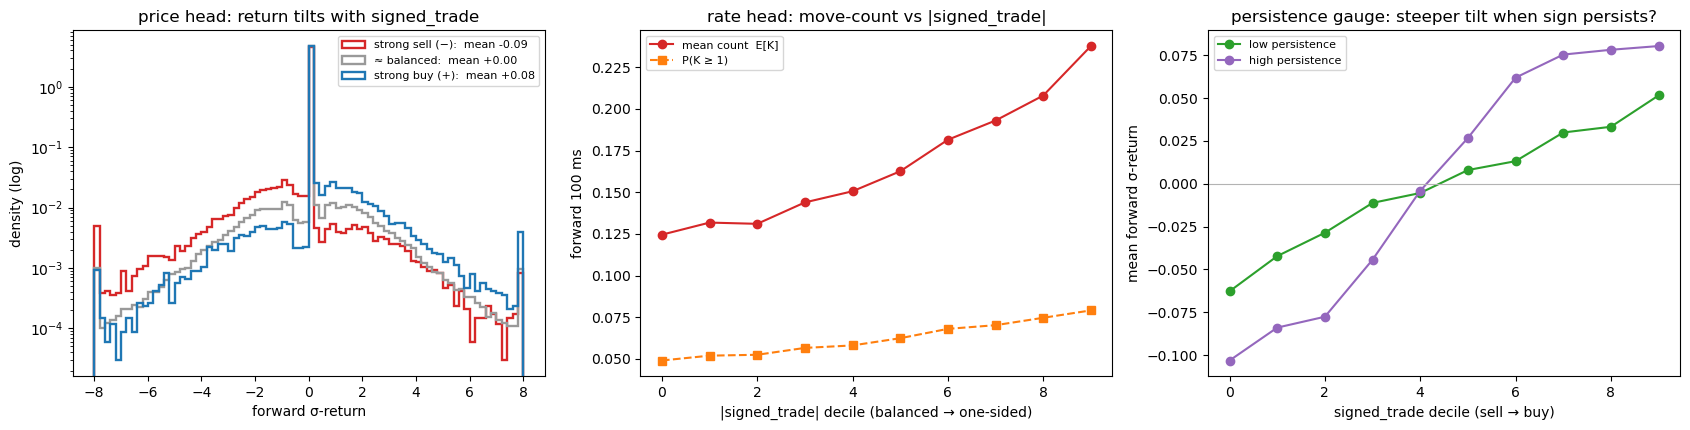

In [9]:
rep_ex = "byb"                                                                  # byb's own flow shown to illustrate; the model uses every venue
signed = st_cache[(rep_ex, SPANS[price_member[rep_ex]])]
absmag = np.abs(st_cache[(rep_ex, SPANS[rate_member[rep_ex]])])
pers   = per_cache[(rep_ex, SPANS[pers_member[rep_ex]])]
fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(17, 4.4))

# price head: forward σ-return distribution across signed_trade buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong sell (−)", signed <= lo, "C3"), ("≈ balanced", (signed > lo) & (signed < hi), "0.6"),
          ("strong buy (+)", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return tilts with signed_trade"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |signed_trade|
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|signed_trade| decile (balanced → one-sided)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count vs |signed_trade|"); axB.legend(fontsize=8)

# the persistence GAUGE: directional edge of signed_trade, split by LOW vs HIGH persistence regime
pm = np.isfinite(pers) & np.isfinite(signed) & np.isfinite(target)
p_med = np.nanmedian(pers[pm])
for lab, m, col in [("low persistence", pm & (pers <= p_med), "C2"), ("high persistence", pm & (pers > p_med), "C4")]:
    s, t = signed[m], target[m]
    dq = np.digitize(s, np.nanpercentile(s, np.arange(10, 100, 10)))
    axC.plot(range(10), [np.nanmean(t[dq == b]) for b in range(10)], "o-", color=col, label=lab)
axC.axhline(0, color="0.7", lw=0.8); axC.set_xlabel("signed_trade decile (sell → buy)")
axC.set_ylabel("mean forward σ-return"); axC.set_title("persistence gauge: steeper tilt when sign persists?"); axC.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the heads need.
**Price head (left):** the forward-return distribution shifts bodily with the *signed* `signed_trade`
— a negative mean for strong-sell flow, positive for strong-buy, balanced between (read the group
means in the legend) — so the sign genuinely carries direction (the feature's main job). **Rate head
(middle):** the diagnostic readout of mean move-count `E[K]` and `P(K ≥ 1)` against `|signed_trade|`.
**Persistence gauge (right):** the directional tilt of `signed_trade` split by low vs high
`flow_sign_persistence` — any visual steepening of the buy-/sell-decile slope in the high-persistence
regime is the picture of the Lillo–Farmer thesis. **But this panel is the *only* positive evidence
for the interaction, and it is not enough.** The quantitative arbiter — the OOS walk-forward marginal
of `signed_trade · persistence` over `signed_trade` alone in §6 — came out at **−0.003** (measured
neutral / slightly negative). So whatever tilt the eye reads here does **not** survive as tradable,
out-of-sample value: `flow_sign_persistence` is **measured-neutral** for its stated purpose. We keep
it (if at all) on the Lillo–Farmer prior, not because the data earns it — see the §10 verdict.

## 8. Input shaping for the network

This is a *different* step from §2. There the question was whether to divide out volatility (the
"regime division") — and for these bounded ratios the answer was *no*. Here we reshape each atom for
the neural network's input — roughly centred, unit-scale, no wild outliers. Pick the **lightest**
transform that does the job. Both atoms are already bounded in `[−1, 1]`, so they have **no** runaway
fat tails to clip — the question is mostly whether to center/scale, or spread out a pile-up near the
edges (`signed_trade` near 0 in balanced flow; `flow_sign_persistence` skewed toward the +1 edge —
order flow is *usually* persistent, so its mass piles high with a tail reaching down toward −1).

signed_trade: range=[-1.000, 1.000] std=0.748 skew=-0.13 excess_kurt=-1.53
    z-score            excess_kurt= -1.53   max|·|=1.4
    robust z           excess_kurt= -1.53   max|·|=1.0
    arcsinh(robust)    excess_kurt= -1.57   max|·|=0.9
    rank-Gaussian      excess_kurt= -0.00   max|·|=4.0


flow_sign_persistence: range=[-0.977, 1.000] std=0.265 skew=-0.91 excess_kurt=0.90
    z-score            excess_kurt=  0.90   max|·|=5.9
    robust z           excess_kurt=  0.90   max|·|=6.3
    arcsinh(robust)    excess_kurt= -0.81   max|·|=2.5
    rank-Gaussian      excess_kurt= -0.00   max|·|=4.8


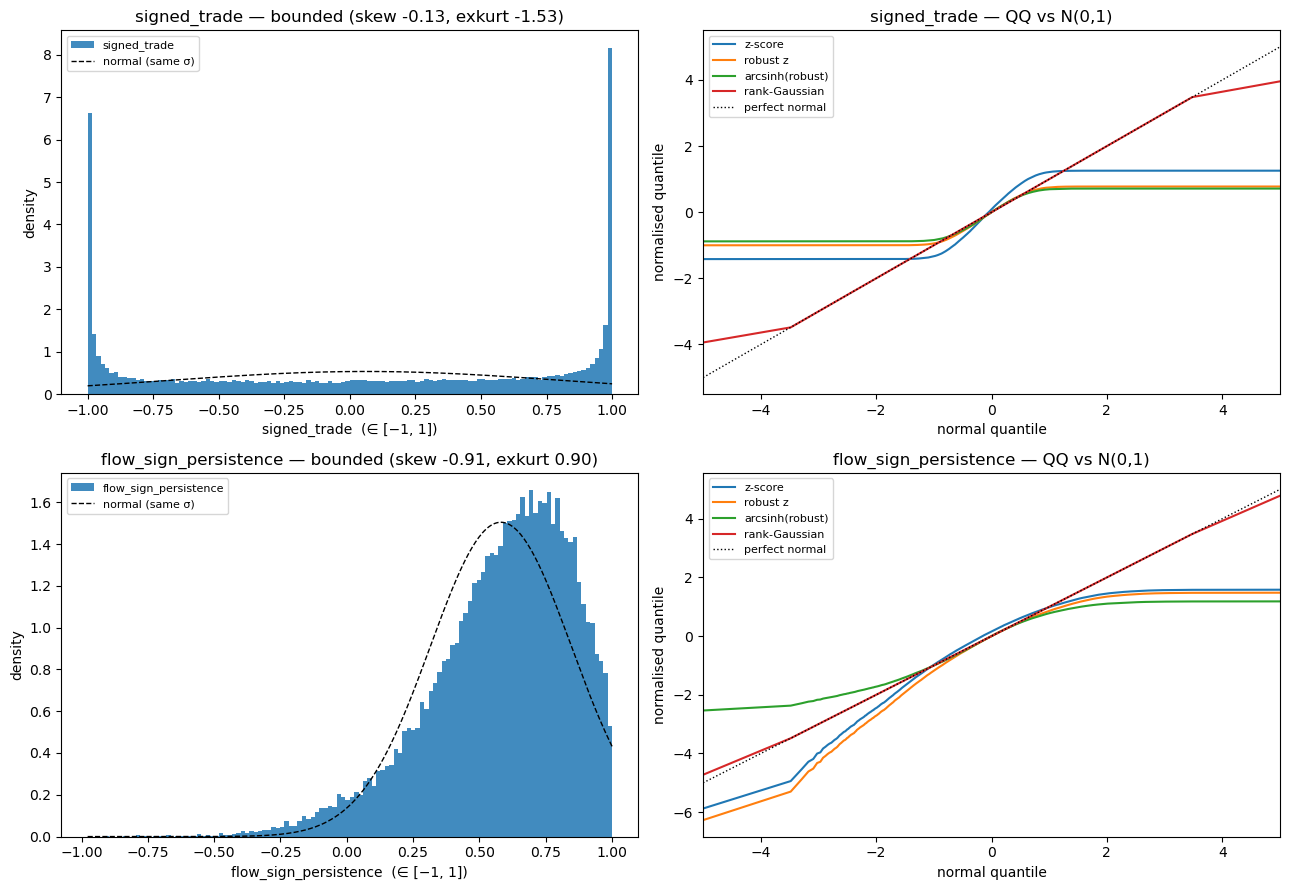

In [10]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = "byb"
atoms = {"signed_trade": st_cache[(rep_ex, SPANS[price_member[rep_ex]])],
         "flow_sign_persistence": per_cache[(rep_ex, SPANS[pers_member[rep_ex]])]}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, (aname, fa) in enumerate(atoms.items()):
    f = fa[np.isfinite(fa)]
    med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
    cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12), "robust z": rz,
            "arcsinh(robust)": np.arcsinh(rz), "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
    print(f"{aname}: range=[{f.min():.3f}, {f.max():.3f}] std={f.std():.3f} skew={skew(f):+.2f} excess_kurt={kurtosis(f):.2f}")
    for name, v in cand.items():
        print(f"    {name:18} excess_kurt={kurtosis(v):>6.2f}   max|·|={np.abs(v).max():.1f}")
    axA, axB = axes[row]
    axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label=aname)
    xg = np.linspace(f.min(), f.max(), 300); axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
    axA.set_xlabel(f"{aname}  (∈ [−1, 1])"); axA.set_ylabel("density")
    axA.set_title(f"{aname} — bounded (skew {skew(f):+.2f}, exkurt {kurtosis(f):.2f})"); axA.legend(fontsize=8)
    q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
    for name, v in cand.items():
        axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
    axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
    axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised quantile")
    axB.set_title(f"{aname} — QQ vs N(0,1)"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** Because both atoms are bounded `[−1, 1]` ratios, neither has runaway outliers.
**`signed_trade`** is near-symmetric (skew **−0.13**) and strongly *platykurtic* (excess kurt
**−1.53** — mass piled toward the ±1 bounds, the harmless direction), with a plain-z `max|·|` of just
**1.4** — so a plain z-score is enough; the heavier maps would only throw away the gradations near the
centre. **`flow_sign_persistence`** is **skewed toward +1** (skew **−0.91**, a long left tail toward
−1 — order flow is usually persistent, so the product `ε·ε_prev` leans +1) with mild positive excess
kurt (**0.90**); a plain z-score leaves a modest **5.9σ** reach into the −1 tail, so a **robust z** (to
center the +1 mode) — or, if you want the tail tamed, an arcsinh — is the lightest transform that
behaves; rank-Gaussian flattens it fully but discards the meaningful gradations. A bounded feature is
the easy case — the opposite of the template's gap, which needed a hard clip.

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for poolable features)

Both atoms are genuine **per-exchange** numbers (not a gap *between* exchanges), so the pool /
single / per-exchange choice is real here — unlike the template's gap, which has no pooled form. The
answer depends on the time-scale, so sweep it and compare the three (shown for the directional atom
`signed_trade`):
- **pooled** — one `signed_trade` over *all* venues' trades on the shared clock;
- **best single** — the single most predictive venue's `signed_trade` (in-sample pick, scored OOS);
- **per-exchange** — all three fed in together.

We score each by **marginal walk-forward** rank-IC over the controls (against byb's next return), at
a short, a medium, and a long span, to see where keeping the venues separate pays off.

In [11]:
# pooled signed_trade: one ε per timestamp across ALL venues = sign(Σ ε over every venue's prints at that timestamp), then E/W.
def _pooled_marks():
    allrx = np.concatenate([trades[ex][0] for ex in EXCHANGES])
    allsg = np.concatenate([trades[ex][1] for ex in EXCHANGES])
    urx, inv = np.unique(allrx, return_inverse=True)
    net = np.bincount(inv, weights=allsg, minlength=len(urx))
    eps = np.sign(net); nz = eps != 0.0
    k = np.searchsorted(merged_ts, urx[nz], "left")
    return k, eps[nz]
pk, peps = _pooled_marks()
def pooled_signed_trade(N):
    return _ema_ratio(pk, peps, np.ones_like(peps), N)

scan = [("short", SPANS[1]), ("medium", SPANS[3]), ("long", SPANS[5])]   # 20 / 500 / 8000 trades
rows = []
for label, N in scan:
    per_ex = [signed_trade(ex, N) for ex in EXCHANGES]
    single_ic = {ex: wf_ic(base + [signed_trade(ex, N)], target) - wf_ic(base, target) for ex in EXCHANGES}
    best_ex = max(single_ic, key=single_ic.get)
    pooled  = round(wf_ic(base + [pooled_signed_trade(N)], target) - wf_ic(base, target), 3)
    single  = round(single_ic[best_ex], 3)
    perex   = round(wf_ic(base + per_ex, target) - wf_ic(base, target), 3)
    rows.append(dict(time_scale=f"{label} (N={N})", pooled=pooled, best_single=f"{single} ({best_ex})", per_exchange=perex))
pl.DataFrame(rows)

time_scale,pooled,best_single,per_exchange
str,f64,str,f64
"""short (N=20)""",0.181,"""0.158 (bin)""",0.167
"""medium (N=500)""",0.048,"""0.048 (bin)""",0.043
"""long (N=8000)""",0.001,"""0.003 (byb)""",0.003


**Conclusion — what THIS block actually shows (not the generic story).** Read the table:

- **At the short scale (N=20), pooling WINS.** Here `pooled 0.181 > per-exchange 0.167 > best-single
  0.158 (bin)`. That is the **opposite** of the usual "per-exchange beats a blurry pool at short
  scales" pattern — on this block the single shared-clock pooled `signed_trade` (one ε per timestamp =
  sign of the net signed-count across *all* venues) is the strongest of the three. Plausibly because
  aggressive flow is highly correlated across these venues at sub-100 ms, so summing their signs
  reinforces rather than blurs, and the pool gets a denser, less-noisy clock. **Per-exchange does not
  pay off at short here** — it lands *between* pooled and best-single.
- **At medium (N=500)** pooled and best-single tie (**0.048**, bin) and edge out per-exchange
  (**0.043**); at **long (N=8000)** all three collapse to ≈0 (pooled 0.001, single/per-ex 0.003) —
  the signed flow has converged to a common, weak drift and the choice no longer matters.

So the genuine finding is: **pooling is at least as good as per-exchange everywhere on this block, and
strictly best at the short scale.** We still feed **all venues** (the cheap default — leadership *can*
rotate on other blocks, and the model can recover the pool from the per-venue inputs), but we do **not**
claim per-exchange beats pooling here — it doesn't. If anything this block argues for *also* carrying
the pooled atom as an input.

## 10. The verdict — honest, post-controls

**Ship `signed_trade`; demote `flow_sign_persistence`.** This is a genuine short-span aggressor-sign
signal — but the headline must be net of the own-flow echo and is dominated by one venue. The honest
numbers from this block:

**`signed_trade` — KEEP (the directional atom).**
- **Marginal value +0.167 OOS over the controls — but it is ~95% bin.** The joint walk-forward
  marginal is **+0.167** (positive in **5/5** OOS folds, block-bootstrap 90% CI **[0.161, 0.173]**),
  but **bin alone is +0.158**; byb (+0.113) and okx (+0.111) together add only **~0.009** over bin.
  The price-head edge is essentially a **single-venue (bin)** result. We keep all three on
  **rotating-leadership** grounds (cheap insurance, ≈0.01 of IC), **not** because "every venue adds
  materially" — it doesn't on this block.
- **Echo-netted, the forward edge is real but smaller than the raw δ=0 headline.** The raw δ=0 IC is
  inflated by the move already underway at the anchor (byb's own trade lands *as* byb's mid moves).
  The echo-netting section partials the trailing `[anchor−100 ms, anchor]` move out of the forward IC;
  what survives — the **echo-netted forward IC** — is the genuinely predictive part. Measured for the
  representative venue **bin** (`EXCHANGES[0]`), the raw forward IC **+0.174** drops to an echo-netted
  **+0.134** once the trailing move is partialled out (backward/echo IC **+0.188**) — so most of the
  raw edge survives as genuine prediction. (The headline **+0.167** above is a *different* statistic —
  the walk-forward Gate-B marginal of all venues' `signed_trade` over the regime controls — **not** the
  echo-netted number; the +0.134 is the single-venue, echo-controlled read.)
- **Cross-venue lead is real edge, not an artifact.** The recording is production-box timing in the
  target datacenter, so a foreign venue's flow moving before byb reflects it is a **genuine,
  exploitable** lead — economic price-discovery or pure latency lead-lag, the mechanism is irrelevant
  to P&L. We feed every venue's `signed_trade` raw and do **not** coarsen the foreign feed to byb's
  cadence (that would only throw the freshness edge away). The *fresher* venue, bin, carries the
  *larger* IC — the opposite of a staleness signature.
- **Regime-invariant (HARD): passed.** Scale ratios across vol buckets **1.07 / 1.03 / 1.09** (≪ 3);
  raw is the right form, proven not assumed. Companion positive in all three vol buckets
  (**0.156 / 0.169 / 0.181**), rising with vol. The one number to watch across blocks is bin's signed
  mean-track **0.055**, just brushing the ~0.05 bar.
- **Feed:** the **signed** atom to **both** heads (the rate head recovers the magnitude and the
  cross-venue cancellation; never a pre-computed `|signed_trade|`). On this block, **also carry the
  pooled `signed_trade`** — it equalled or beat per-exchange everywhere and **won at the short scale**
  (§9: pooled 0.181 > per-exchange 0.167 > best-single 0.158). No σ/λ-division (bounded ratio).

**`flow_sign_persistence` — DO NOT ship as an interaction; measured-neutral.**
- Its sole stated purpose (Lillo–Farmer "trust the run") is that `signed_trade · persistence` adds
  **over** `signed_trade`. The OOS walk-forward marginal is **−0.003** — i.e. **it adds nothing**
  (slightly negative). The §7 "steeper tilt" panel is the only positive evidence and it does not
  survive OOS. Its own *signed* value is directionless by design (≈0 price IC). **We do not recommend
  it.** If kept at all, it is on the Lillo–Farmer **prior only** (a cheap auxiliary input), explicitly
  **not** earned by the data here. (It is bounded and passes the same scale-invariance gate — scale
  **1.07** — so it does no harm, but it pays nothing.)

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version — **§4 is
      bit-exact (max|diff| = 0.0, integer ±1 marks) on a real block at the shipped span 20 and span
      100, both atoms × all venues**
- [ ] the parity check (§4) and tests, passing
- [x] the gate results recorded — marginal +0.167 (≈0.158 bin-dominated); echo-netted forward IC
      stays positive (**+0.134** for the representative venue bin, run for one venue — extend to a
      per-leg sweep before shipping the cross-venue legs); **persistence interaction −0.003 (rejected)**, invariance ≤1.09× (passed)
- [ ] the chosen heads and time-scales written down (price head: `signed_trade` N=20 per venue +
      pooled; yardstick spans `YARDSTICK_N=10000`)
- [x] the data quirks handled (bad zero-price/zero-qty prints filtered; the venue-specific aggressor
      convention via `io._trade_lifts_ask`; same-timestamp prints collapsed to one signed event; the
      lag `ε_{t−1}` stepping once per venue-timestamp)